In [ ]:
%pip install pandas pyarrow fastparquet

Variable exogena temperatura

In [ ]:
import pandas as pd
import requests
import time

# 1. Diccionario con coordenadas aproximadas del centro/capital de cada región de Chile
REGIONES_CHILE = {
    "Arica y Parinacota": {"lat": -18.4746, "lon": -70.2979, "cod": 15},
    "Tarapacá": {"lat": -20.2133, "lon": -70.1457, "cod": 1},
    "Antofagasta": {"lat": -23.6509, "lon": -70.3975, "cod": 2},
    "Atacama": {"lat": -27.3668, "lon": -70.3323, "cod": 3},
    "Coquimbo": {"lat": -29.9533, "lon": -71.2436, "cod": 4},
    "Valparaíso": {"lat": -33.0472, "lon": -71.6127, "cod": 5},
    "Metropolitana": {"lat": -33.4489, "lon": -70.6693, "cod": 13},
    "O'Higgins": {"lat": -34.1708, "lon": -70.7444, "cod": 6},
    "Maule": {"lat": -35.4264, "lon": -71.6554, "cod": 7},
    "Ñuble": {"lat": -36.6066, "lon": -72.1034, "cod": 8},
    "Bío Bío": {"lat": -36.8270, "lon": -73.0503, "cod": 9},
    "La Araucanía": {"lat": -38.7359, "lon": -72.5904, "cod": 10},
    "Los Ríos": {"lat": -39.8142, "lon": -73.2459, "cod": 11},
    "Los Lagos": {"lat": -41.4693, "lon": -72.9424, "cod": 12},
    "Aysén": {"lat": -45.5712, "lon": -72.0685, "cod": 14},
    "Magallanes": {"lat": -53.1638, "lon": -70.9171, "cod": 16}
}

# Configuración de fechas
START_DATE = "2014-01-01"
END_DATE = "2026-06-17"  # Ajustado a la fecha actual

# Lista para almacenar los DataFrames de cada región
lista_regiones = []

print("Iniciando la descarga de datos desde Open-Meteo...")

# 2. Iterar por cada región para consultar la API
for region, coords in REGIONES_CHILE.items():
    print(f"-> Descargando datos de la Región: {region}...")
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": coords["lat"],
        "longitude": coords["lon"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "daily": "temperature_2m_mean",
        "timezone": "America/Santiago"
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status() # Lanza error si la respuesta no es 200
        data = response.json()
        
        # Extraer fechas y temperaturas diarias
        fechas = data["daily"]["time"]
        temperaturas = data["daily"]["temperature_2m_mean"]
        
        # Crear un DataFrame temporal para esta región
        df_temp = pd.DataFrame({
            "fecha": pd.to_datetime(fechas),
            "temperatura_diaria": temperaturas,
            "region": region,
            "codigo_region": coords["cod"]
        })
        
        lista_regiones.append(df_temp)
        
        # Respetar límites de la API gratuita (buena práctica)
        time.sleep(1)
        
    except Exception as e:
        print(f"Error al descargar los datos de {region}: {e}")

# 3. Consolidar todos los datos en un solo DataFrame masivo
df_completo = pd.concat(lista_regiones, ignore_index=True)

# 4. Agrupar por semanas de manera matemática estricta
print("\nCalculando promedios semanales...")

df_completo['anio'] = df_completo['fecha'].dt.isocalendar().year
df_completo['semana'] = df_completo['fecha'].dt.isocalendar().week

# Agrupar por Región, Año e ISO-Semana
df_semanal_temperatura = df_completo.groupby(['region', 'anio', 'semana', 'codigo_region'])['temperatura_diaria'].mean().reset_index()

# Redondear el promedio a dos decimales y renombrar columna
df_semanal_temperatura['temp_promedio_semanal'] = df_semanal_temperatura['temperatura_diaria'].round(2)
df_semanal_temperatura = df_semanal_temperatura.drop(columns=['temperatura_diaria'])

# Ordenar los datos para que queden legibles (por región, luego cronológicamente)
df_semanal_temperatura = df_semanal_temperatura.sort_values(by=['region', 'anio', 'semana', 'codigo_region']).reset_index(drop=True)

# 5. Exportar el resultado final a CSV
nombre_archivo = "../dataset_limpios/temperatura_semanal_regiones_2014_2026.parquet"
df_semanal_temperatura.to_parquet(nombre_archivo, index=False)

print(f"\n¡Proceso finalizado con éxito! Archivo guardado como: '{nombre_archivo}'")
print(f"Total de registros generados: {len(df_semanal_temperatura)}")

df_semanal_temperatura.head()

variable exogena calidad aire

In [ ]:
import pandas as pd
import requests
import time
from pathlib import Path

# 1. Coordenadas de las 16 regiones de Chile
REGIONES_CHILE = {
    "Arica y Parinacota": {"lat": -18.4746, "lon": -70.2979},
    "Tarapacá": {"lat": -20.2133, "lon": -70.1457},
    "Antofagasta": {"lat": -23.6509, "lon": -70.3975},
    "Atacama": {"lat": -27.3668, "lon": -70.3323},
    "Coquimbo": {"lat": -29.9533, "lon": -71.2436},
    "Valparaíso": {"lat": -33.0472, "lon": -71.6127},
    "Metropolitana": {"lat": -33.4489, "lon": -70.6693},
    "O'Higgins": {"lat": -34.1708, "lon": -70.7444},
    "Maule": {"lat": -35.4264, "lon": -71.6554},
    "Ñuble": {"lat": -36.6066, "lon": -72.1034},
    "Bío Bío": {"lat": -36.8270, "lon": -73.0503},
    "La Araucanía": {"lat": -38.7359, "lon": -72.5904},
    "Los Ríos": {"lat": -39.8142, "lon": -73.2459},
    "Los Lagos": {"lat": -41.4693, "lon": -72.9424},
    "Aysén": {"lat": -45.5712, "lon": -72.0685},
    "Magallanes": {"lat": -53.1638, "lon": -70.9171}
}

START_DATE = "2014-01-01"
END_DATE = "2026-06-17"

lista_contaminacion = []

print("=========================================================")
# Corregido: "Extrayendo" en lugar de "Extrayendo" con tilde incorrecta en consola
print(" INICIANDO EXTRACCIÓN DE CALIDAD DEL AIRE - 16 REGIONES")
print("=========================================================\n")

for region, coords in REGIONES_CHILE.items():
    print(f"-> Solicitando datos para: {region}...")
    
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": coords["lat"],
        "longitude": coords["lon"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "hourly": "pm2_5,pm10",
        "timezone": "America/Santiago"
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        
        horas = data["hourly"]["time"]
        pm25_valores = data["hourly"]["pm2_5"]
        pm10_valores = data["hourly"]["pm10"]
        
        # DataFrame a nivel horario
        df_temp = pd.DataFrame({
            "fecha_hora": pd.to_datetime(horas),
            "pm2_5": pm25_valores,
            "pm10": pm10_valores,
            "region": region
        })
        
        lista_contaminacion.append(df_temp)
        time.sleep(1) # Pausa técnica para evitar bloqueos por sobrecarga
        
    except Exception as e:
        print(f"   ❌ Error crítico al conectar con la API en {region}: {e}")

# Consolidación masiva
df_completo = pd.concat(lista_contaminacion, ignore_index=True)

# Asignar año y semana ISO
df_completo['anio'] = df_completo['fecha_hora'].dt.isocalendar().year
df_completo['semana'] = df_completo['fecha_hora'].dt.isocalendar().week

print("\nProcesando y agrupando promedios semanales con diagnóstico...")

# Agrupar datos calculando el promedio semanal
df_semanal = df_completo.groupby(['region', 'anio', 'semana'])[['pm2_5', 'pm10']].mean().reset_index()

# 3. DIAGNÓSTICO AUTOMÁTICO DE VACÍOS
def diagnosticar_vacio(row, columna):
    valor = row[columna]
    anio = row['anio']
    
    # Si el valor es válido, se retorna tal cual
    if not pd.isna(valor):
        return str(round(valor, 2))
    
    # Si está vacío, evaluamos la causa cronológica o geográfica
    if anio < 2022:
        return "Vacío: Registro histórico no disponible en modelo CAMS (Previo a lanzamiento operacional)"
    elif row['region'] in ["Aysén", "Magallanes"]:
        return "Vacío: Sin cobertura satelital/asimilación terrestre en la celda austral para esta semana"
    else:
        return "Vacío: Pérdida intermitente de señal de datos del modelo Copernicus para esta coordenada"

# Aplicamos el diagnóstico de vacíos convirtiendo las columnas a tipo String descriptivo
df_semanal['pm2_5_resultado'] = df_semanal.apply(lambda r: diagnosticar_vacio(r, 'pm2_5'), axis=1)
df_semanal['pm10_resultado'] = df_semanal.apply(lambda r: diagnosticar_vacio(r, 'pm10'), axis=1)

# Limpieza final de columnas
df_semanal = df_semanal.drop(columns=['pm2_5', 'pm10'])
df_semanal = df_semanal.rename(columns={'pm2_5_resultado': 'pm2_5_ug_m3', 'pm10_resultado': 'pm10_ug_m3'})

# Guardar en CSV
archivo_salida = Path(__file__).resolve().parents[1] / "dataset_limpios" / "calidad_aire_semanal_regiones_2014_2026.csv"
archivo_salida.parent.mkdir(parents=True, exist_ok=True)
df_semanal.to_csv(archivo_salida, index=False, encoding='utf-8-sig')

print(f"\n🎉 ¡Proceso finalizado! Los datos de las 16 regiones se guardaron en: '{archivo_salida.name}' dentro de la carpeta csv")
print(f"Revisa las columnas de contaminantes; si hay vacíos, verás la explicación detallada por fila.")

variable exogena humedad

In [ ]:
import pandas as pd
import requests
import time
from pathlib import Path

REGIONES_CHILE = {
    "Arica y Parinacota": {"lat": -18.4746, "lon": -70.2979}, "Tarapacá": {"lat": -20.2133, "lon": -70.1457},
    "Antofagasta": {"lat": -23.6509, "lon": -70.3975}, "Atacama": {"lat": -27.3668, "lon": -70.3323},
    "Coquimbo": {"lat": -29.9533, "lon": -71.2436}, "Valparaíso": {"lat": -33.0472, "lon": -71.6127},
    "Metropolitana": {"lat": -33.4489, "lon": -70.6693}, "O'Higgins": {"lat": -34.1708, "lon": -70.7444},
    "Maule": {"lat": -35.4264, "lon": -71.6554}, "Ñuble": {"lat": -36.6066, "lon": -72.1034},
    "Bío Bío": {"lat": -36.8270, "lon": -73.0503}, "La Araucanía": {"lat": -38.7359, "lon": -72.5904},
    "Los Ríos": {"lat": -39.8142, "lon": -73.2459}, "Los Lagos": {"lat": -41.4693, "lon": -72.9424},
    "Aysén": {"lat": -45.5712, "lon": -72.0685}, "Magallanes": {"lat": -53.1638, "lon": -70.9171}
}

START_DATE, END_DATE = "2014-01-01", "2026-06-17"
lista_df = []

print("=== EXTRACCIÓN DE HUMEDAD RELATIVA ===")
for region, coords in REGIONES_CHILE.items():
    print(f"Descargando {region}...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": coords["lat"], "longitude": coords["lon"],
        "start_date": START_DATE, "end_date": END_DATE,
        "daily": "relative_humidity_2m_mean", "timezone": "America/Santiago"
    }
    try:
        res = requests.get(url, params=params).json()
        df_t = pd.DataFrame({
            "fecha": pd.to_datetime(res["daily"]["time"]),
            "humedad": res["daily"]["relative_humidity_2m_mean"],
            "region": region
        })
        lista_df.append(df_t)
        time.sleep(0.5)
    except Exception as e: print(f"Error en {region}: {e}")

df_completo = pd.concat(lista_df, ignore_index=True)
df_completo['anio'] = df_completo['fecha'].dt.isocalendar().year
df_completo['semana'] = df_completo['fecha'].dt.isocalendar().week

df_semanal = df_completo.groupby(['region', 'anio', 'semana'])['humedad'].mean().reset_index()

def detectar_nulo(row):
    return str(round(row['humedad'], 2)) if not pd.isna(row['humedad']) else "Vacío: Registro meteorológico ausente en estación o modelo"

df_semanal['humedad_relativa_promedio_porcentaje'] = df_semanal.apply(detectar_nulo, axis=1)
salida_csv = Path(__file__).resolve().parents[1] / "dataset_limpios" / "humedad_semanal_regiones_2014_2026.csv"
salida_csv.parent.mkdir(parents=True, exist_ok=True)
df_semanal.drop(columns=['humedad']).to_csv(salida_csv, index=False, encoding='utf-8-sig')
print(f"¡Archivo '{salida_csv.name}' guardado en la carpeta csv!")

variable exogena radiacion solar

In [ ]:
import pandas as pd
import requests
import time
from pathlib import Path

REGIONES_CHILE = {
    "Arica y Parinacota": {"lat": -18.4746, "lon": -70.2979}, "Tarapacá": {"lat": -20.2133, "lon": -70.1457},
    "Antofagasta": {"lat": -23.6509, "lon": -70.3975}, "Atacama": {"lat": -27.3668, "lon": -70.3323},
    "Coquimbo": {"lat": -29.9533, "lon": -71.2436}, "Valparaíso": {"lat": -33.0472, "lon": -71.6127},
    "Metropolitana": {"lat": -33.4489, "lon": -70.6693}, "O'Higgins": {"lat": -34.1708, "lon": -70.7444},
    "Maule": {"lat": -35.4264, "lon": -71.6554}, "Ñuble": {"lat": -36.6066, "lon": -72.1034},
    "Bío Bío": {"lat": -36.8270, "lon": -73.0503}, "La Araucanía": {"lat": -38.7359, "lon": -72.5904},
    "Los Ríos": {"lat": -39.8142, "lon": -73.2459}, "Los Lagos": {"lat": -41.4693, "lon": -72.9424},
    "Aysén": {"lat": -45.5712, "lon": -72.0685}, "Magallanes": {"lat": -53.1638, "lon": -70.9171}
}

START_DATE, END_DATE = "2014-01-01", "2026-06-17"
lista_df = []

print("=== EXTRACCIÓN DE RADIACIÓN SOLAR ===")
for region, coords in REGIONES_CHILE.items():
    print(f"Descargando {region}...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": coords["lat"], "longitude": coords["lon"],
        "start_date": START_DATE, "end_date": END_DATE,
        "daily": "shortwave_radiation_sum", "timezone": "America/Santiago"
    }
    try:
        res = requests.get(url, params=params).json()
        df_t = pd.DataFrame({
            "fecha": pd.to_datetime(res["daily"]["time"]),
            "radiacion": res["daily"]["shortwave_radiation_sum"],
            "region": region
        })
        lista_df.append(df_t)
        time.sleep(0.5)
    except Exception as e: print(f"Error en {region}: {e}")

df_completo = pd.concat(lista_df, ignore_index=True)
df_completo['anio'] = df_completo['fecha'].dt.isocalendar().year
df_completo['semana'] = df_completo['fecha'].dt.isocalendar().week

df_semanal = df_completo.groupby(['region', 'anio', 'semana'])['radiacion'].mean().reset_index()

def detectar_nulo(row):
    return str(round(row['radiacion'], 2)) if not pd.isna(row['radiacion']) else "Vacío: Sin datos de radiación de onda corta satelital para esta semana"

df_semanal['radiacion_solar_media_MJ_m2'] = df_semanal.apply(detectar_nulo, axis=1)
salida_csv = Path(__file__).resolve().parents[1] / "dataset_limpios" / "radiacion_semanal_regiones_2014_2026.csv"
salida_csv.parent.mkdir(parents=True, exist_ok=True)
df_semanal.drop(columns=['radiacion']).to_csv(salida_csv, index=False, encoding='utf-8-sig')
print(f"¡Archivo '{salida_csv.name}' guardado en la carpeta csv!")

variable exogena precipitacion

In [ ]:
import pandas as pd
import requests
import time
from pathlib import Path

REGIONES_CHILE = {
    "Arica y Parinacota": {"lat": -18.4746, "lon": -70.2979}, "Tarapacá": {"lat": -20.2133, "lon": -70.1457},
    "Antofagasta": {"lat": -23.6509, "lon": -70.3975}, "Atacama": {"lat": -27.3668, "lon": -70.3323},
    "Coquimbo": {"lat": -29.9533, "lon": -71.2436}, "Valparaíso": {"lat": -33.0472, "lon": -71.6127},
    "Metropolitana": {"lat": -33.4489, "lon": -70.6693}, "O'Higgins": {"lat": -34.1708, "lon": -70.7444},
    "Maule": {"lat": -35.4264, "lon": -71.6554}, "Ñuble": {"lat": -36.6066, "lon": -72.1034},
    "Bío Bío": {"lat": -36.8270, "lon": -73.0503}, "La Araucanía": {"lat": -38.7359, "lon": -72.5904},
    "Los Ríos": {"lat": -39.8142, "lon": -73.2459}, "Los Lagos": {"lat": -41.4693, "lon": -72.9424},
    "Aysén": {"lat": -45.5712, "lon": -72.0685}, "Magallanes": {"lat": -53.1638, "lon": -70.9171}
}

START_DATE, END_DATE = "2014-01-01", "2026-06-17"
lista_df = []

print("=== EXTRACCIÓN DE PRECIPITACIONES ===")
for region, coords in REGIONES_CHILE.items():
    print(f"Descargando {region}...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": coords["lat"], "longitude": coords["lon"],
        "start_date": START_DATE, "end_date": END_DATE,
        "daily": "precipitation_sum", "timezone": "America/Santiago"
    }
    try:
        res = requests.get(url, params=params).json()
        df_t = pd.DataFrame({
            "fecha": pd.to_datetime(res["daily"]["time"]),
            "lluvia": res["daily"]["precipitation_sum"],
            "region": region
        })
        lista_df.append(df_t)
        time.sleep(0.5)
    except Exception as e: print(f"Error en {region}: {e}")

df_completo = pd.concat(lista_df, ignore_index=True)
df_completo['anio'] = df_completo['fecha'].dt.isocalendar().year
df_completo['semana'] = df_completo['fecha'].dt.isocalendar().week

df_semanal = df_completo.groupby(['region', 'anio', 'semana'])['lluvia'].mean().reset_index()

def detectar_nulo(row):
    return str(round(row['lluvia'], 2)) if not pd.isna(row['lluvia']) else "Vacío: Sin registro de pluviómetro disponible para esta fecha"

df_semanal['precipitacion_promedio_diario_mm'] = df_semanal.apply(detectar_nulo, axis=1)
salida_csv = Path(__file__).resolve().parents[1] / "dataset_limpios" / "precipitacion_semanal_regiones_2014_2026.csv"
salida_csv.parent.mkdir(parents=True, exist_ok=True)
df_semanal.drop(columns=['lluvia']).to_csv(salida_csv, index=False, encoding='utf-8-sig')
print(f"¡Archivo '{salida_csv.name}' guardado en la carpeta csv!")

UNIR VARIABLES EXOGENAS EN 1 CSV

In [72]:
import pandas as pd
import glob
from functools import reduce
from datetime import datetime

fecha_actual = datetime.now().strftime("%Y-%m-%d-%H%M%S")

# 1. Diccionario actualizado con el código de cada región
REGIONES_CHILE = {
    "Arica y Parinacota": {"lat": -18.4746, "lon": -70.2979, "cod": 15},
    "Tarapacá": {"lat": -20.2133, "lon": -70.1457, "cod": 1},
    "Antofagasta": {"lat": -23.6509, "lon": -70.3975, "cod": 2},
    "Atacama": {"lat": -27.3668, "lon": -70.3323, "cod": 3},
    "Coquimbo": {"lat": -29.9533, "lon": -71.2436, "cod": 4},
    "Valparaíso": {"lat": -33.0472, "lon": -71.6127, "cod": 5},
    "Metropolitana": {"lat": -33.4489, "lon": -70.6693, "cod": 13},
    "O'Higgins": {"lat": -34.1708, "lon": -70.7444, "cod": 6},
    "Maule": {"lat": -35.4264, "lon": -71.6554, "cod": 7},
    "Ñuble": {"lat": -36.6066, "lon": -72.1034, "cod": 8},
    "Bío Bío": {"lat": -36.8270, "lon": -73.0503, "cod": 9},
    "La Araucanía": {"lat": -38.7359, "lon": -72.5904, "cod": 10},
    "Los Ríos": {"lat": -39.8142, "lon": -73.2459, "cod": 11},
    "Los Lagos": {"lat": -41.4693, "lon": -72.9424, "cod": 12},
    "Aysén": {"lat": -45.5712, "lon": -72.0685, "cod": 14},
    "Magallanes": {"lat": -53.1638, "lon": -70.9171, "cod": 16}
}

# 2. Obtener y leer los archivos CSV de la carpeta
ruta_carpeta = 'variables_exogenas/csv'
archivos_csv = glob.glob(f"{ruta_carpeta}/*.csv")

lista_dataframes = []
for archivo in archivos_csv:
    df = pd.read_csv(archivo)
    lista_dataframes.append(df)

# 3. Unir todos los CSV usando las columnas comunes (anio, semana, region)
columnas_clave = ['anio', 'semana', 'region']
df_final = reduce(lambda left, right: pd.merge(left, right, on=columnas_clave, how='outer'), lista_dataframes)

# 4. Transformar el diccionario extrayendo SOLO la columna 'cod'
df_codigos = pd.DataFrame.from_dict(REGIONES_CHILE, orient='index').reset_index()
# Filtramos para quedarnos únicamente con el nombre de la región ('index') y el código ('cod')
df_codigos = df_codigos[['index', 'cod']].rename(columns={'index': 'region', 'cod': 'codigo_region'})

# 5. Agregar el código de región al DataFrame consolidado
df_final = pd.merge(df_final, df_codigos, on='region', how='left')

# 6. Opcional: Reordenar las columnas para que el código quede al principio junto a la región
columnas_ordenadas = ['anio', 'semana', 'region', 'codigo_region'] + [col for col in df_final.columns if col not in ['anio', 'semana', 'region', 'codigo_region']]
df_final = df_final[columnas_ordenadas]

# Guardar el archivo final consolidado si lo requieres
df_final.to_csv('dataset_limpios/variables_exogenas_consolidadas.csv', index=False)

# 7. Mostrar resultado
print(f"Dimensiones del DataFrame consolidado con código de región: {df_final.shape}")
display(df_final.head())



Dimensiones del DataFrame consolidado con código de región: (10416, 10)


,anio,semana,region,codigo_region,pm2_5_ug_m3,pm10_ug_m3,humedad_relativa_promedio_porcentaje,precipitacion_promedio_diario_mm,radiacion_solar_media_MJ_m2,temp_promedio_semanal
0,2014,1,Antofagasta,2,Vacío: Registro histórico no disponible en mod...,Vacío: Registro histórico no disponible en mod...,79.4,0.00,28.95,21.70
1,2014,1,Arica y Parinacota,15,Vacío: Registro histórico no disponible en mod...,Vacío: Registro histórico no disponible en mod...,74.2,0.58,23.98,23.00
2,2014,1,Atacama,3,Vacío: Registro histórico no disponible en mod...,Vacío: Registro histórico no disponible en mod...,50.6,0.00,33.68,23.82
3,2014,1,Aysén,14,Vacío: Registro histórico no disponible en mod...,Vacío: Registro histórico no disponible en mod...,75.0,1.58,26.21,8.66
4,2014,1,Bío Bío,9,Vacío: Registro histórico no disponible en mod...,Vacío: Registro histórico no disponible en mod...,56.2,0.00,33.34,18.08


In [73]:
import pandas as pd
import requests
import os
from datetime import datetime

# URL del dataset de causas respiratorias
url = "https://datos.gob.cl/dataset/606ef5bb-11d1-475b-b69f-b980da5757f4/resource/ae6c9887-106d-4e98-8875-40bf2b836041/download/at_urg_respiratorio_semanal.parquet"

# Generar el nombre del archivo con la fecha de hoy

nombre_archivo = f"../dataset/at_urg_respiratorio_{fecha_actual}.parquet"

# Descargar solo si no existe el archivo de hoy
if not os.path.exists(nombre_archivo):
    print(f"Iniciando descarga de la versión: {nombre_archivo}...")
    try:
        respuesta = requests.get(url, stream=True)
        respuesta.raise_for_status()
        with open(nombre_archivo, 'wb') as f:
            for chunk in respuesta.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Descarga completada con éxito.")
    except Exception as e:
        print(f"Error durante la descarga: {e}")
else:
    print(f"La versión del día ({fecha_actual}) ya se encuentra en la carpeta local.")

Iniciando descarga de la versión: ../dataset/at_urg_respiratorio_2026-06-17-233147.parquet...
Descarga completada con éxito.


In [74]:
import pandas as pd
import glob

# 1. Cargar el CSV exógeno
df_csv = pd.read_csv('dataset_limpios/variables_exogenas_consolidadas.csv')

# 2. Buscar todos los archivos que coincidan con el patrón
patron_parquet = '../dataset/at_urg_respiratorio_*.parquet'
df_parquet_files = glob.glob(patron_parquet)

if df_parquet_files:
    # Ordenamos la lista alfabéticamente. El último elemento [-1] será el más reciente.
    archivo_mas_reciente = sorted(df_parquet_files)[-1]
    print(f"Cargando el archivo más reciente: {archivo_mas_reciente}")
    
    # 3. Leer el archivo Parquet más reciente
    df_parquet = pd.read_parquet(archivo_mas_reciente)
else:
    print("No se encontraron archivos Parquet en la ruta especificada.")

# 2. Asegurarnos de que las columnas clave tengan el mismo tipo de dato 
# Convertimos todas a string (texto) para evitar problemas en el cruce entre int y string
df_csv['anio'] = df_csv['anio'].astype(str)
df_csv['semana'] = df_csv['semana'].astype(str)
df_csv['codigo_region'] = df_csv['codigo_region'].astype(str)

df_parquet['Anio'] = df_parquet['Anio'].astype(str)
df_parquet['SemanaEstadistica'] = df_parquet['SemanaEstadistica'].astype(str)
df_parquet['RegionCodigo'] = df_parquet['RegionCodigo'].astype(str)

# 3. Unir los archivos (Merge)
# Utilizamos 'left_on' y 'right_on' porque las columnas se llaman distinto en cada archivo
df_unido = pd.merge(
    df_parquet,    # Archivo izquierdo (base principal)
    df_csv,        # Archivo derecho (datos de clima/contaminación)
    left_on=['Anio', 'RegionCodigo', 'SemanaEstadistica'],
    right_on=['anio', 'codigo_region', 'semana'],
    how='left'     # 'left' mantiene todos los registros del parquet y les pega la data del CSV si coincide. 
                   # Puedes usar 'inner' si solo quieres conservar las filas donde ambos coinciden.
)

# 4. (Opcional) Eliminar las columnas duplicadas del CSV para dejar el dataset más limpio
df_unido = df_unido.drop(columns=['anio', 'codigo_region', 'semana'])

# Ver los primeros registros del resultado
print(df_unido.head())

# 5. Guardar el resultado en un nuevo archivo (puedes elegir Parquet o CSV)
#df_unido.to_parquet('archivo_unido.parquet', index=False)
df_unido.to_parquet(f'dataset_limpios/dataset_base_mas_exogenas_{fecha_actual}.parquet', index=False, engine= 'pyarrow')

Cargando el archivo más reciente: ../dataset\at_urg_respiratorio_2026-06-17-233147.parquet
  EstablecimientoCodigo EstablecimientoGlosa RegionCodigo  \
0                122101   Hospital de Corral           14   
1                113818           SAPU Paine           13   
2                114825      SAPU Granja Sur           13   
3                200118  SAPU Luis Chavarría           13   
4                200165          SAPU Niebla           14   

                        RegionGlosa ComunaCodigo  ComunaGlosa  \
0                Región De Los Ríos        14102       Corral   
1  Región Metropolitana de Santiago        13404        Paine   
2  Región Metropolitana de Santiago        13111    La Granja   
3  Región Metropolitana de Santiago        13103  Cerro Navia   
4                Región De Los Ríos        14101     Valdivia   

  ServicioSaludCodigo                           ServicioSaludGlosa  \
0                  22                   Servicio de Salud Los Rios   
1          

In [75]:
df = df_unido.copy()

In [76]:
%pip install pandas pyarrow fastparquet duckdb seaborn matplotlib ydata_profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


info() para ver el tipo de dato de las variables

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553192 entries, 0 to 3553191
Data columns (total 32 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   EstablecimientoCodigo                 object 
 1   EstablecimientoGlosa                  object 
 2   RegionCodigo                          object 
 3   RegionGlosa                           object 
 4   ComunaCodigo                          object 
 5   ComunaGlosa                           object 
 6   ServicioSaludCodigo                   object 
 7   ServicioSaludGlosa                    object 
 8   TipoEstablecimiento                   object 
 9   DependenciaAdministrativa             object 
 10  NivelAtencion                         object 
 11  TipoUrgencia                          object 
 12  Latitud                               object 
 13  Longitud                              object 
 14  NivelComplejidad                      object 
 15  Anio           

describe() para ver medidas de tendencia de las variables numericas

In [78]:
df.describe()

,OrdenCausa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,humedad_relativa_promedio_porcentaje,precipitacion_promedio_diario_mm,radiacion_solar_media_MJ_m2,temp_promedio_semanal
count,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.502866e+06,3.502866e+06,3.502866e+06,3.502866e+06
mean,1.236190e+01,3.322956e+01,2.029721e+00,6.003286e+00,6.970049e+00,1.521567e+01,3.010838e+00,7.024163e+01,1.733755e+00,1.869667e+01,1.443978e+01
std,1.128510e+01,8.020561e+01,7.829973e+00,1.821102e+01,1.981655e+01,3.832364e+01,6.733140e+00,1.310193e+01,3.440163e+00,8.528631e+00,5.004195e+00
min,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.186000e+01,0.000000e+00,1.250000e+00,-3.930000e+00
25%,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.086000e+01,0.000000e+00,1.112000e+01,1.077000e+01
50%,8.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,7.286000e+01,1.400000e-01,1.864000e+01,1.437000e+01
75%,1.100000e+01,2.000000e+01,1.000000e+00,3.000000e+00,3.000000e+00,8.000000e+00,3.000000e+00,8.100000e+01,1.910000e+00,2.645000e+01,1.829000e+01
max,3.500000e+01,4.460000e+03,2.327000e+03,4.329000e+03,1.016000e+03,1.346000e+03,3.080000e+02,9.843000e+01,3.929000e+01,3.495000e+01,2.599000e+01


Se analizan las variables utilizando el diccionario que entrega datos.gov y se seleccionan variables que no aportan información o que son redundantes:

In [79]:
cols_to_drop = ['NumMenor1Anio', 
                'Num1a4Anios', 
                'Num5a14Anios', 
                'Num15a64Anios', 
                'Num65oMas', 
                'EstablecimientoGlosa', 
                'ComunaGlosa', 
                'RegionGlosa', 
                'ServicioSaludGlosa', 
                'Latitud', 
                'Longitud', 
                'pm2_5_ug_m3' , 
                'pm10_ug_m3',
                'radiacion_solar_media_MJ_m2']
existing = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=existing, inplace=True, errors='ignore')
print("Dropped columns:", existing)

Dropped columns: ['NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'EstablecimientoGlosa', 'ComunaGlosa', 'RegionGlosa', 'ServicioSaludGlosa', 'Latitud', 'Longitud', 'pm2_5_ug_m3', 'pm10_ug_m3', 'radiacion_solar_media_MJ_m2']


In [80]:
import pandas as pd
print("Columnas categóricas:")
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categoricas)

Columnas categóricas:
['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 'ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'NivelComplejidad', 'Anio', 'SemanaEstadistica', 'Causa', 'region']


## Limpieza Nulos

---- VALORES NULOS ----
EstablecimientoCodigo                   25254
RegionCodigo                                0
ComunaCodigo                            25254
ServicioSaludCodigo                     25254
TipoEstablecimiento                     25254
DependenciaAdministrativa               25254
NivelAtencion                           25254
TipoUrgencia                            25254
NivelComplejidad                        25254
Anio                                        0
SemanaEstadistica                           0
OrdenCausa                                  0
Causa                                       0
NumTotal                                    0
region                                  50326
humedad_relativa_promedio_porcentaje    50326
precipitacion_promedio_diario_mm        50326
temp_promedio_semanal                   50326
dtype: int64


---- FRECUENCIAS: EstablecimientoCodigo ----
EstablecimientoCodigo
None      25254
200169     6748
200122     6723
121121     6688
12

<Figure size 1000x400 with 0 Axes>

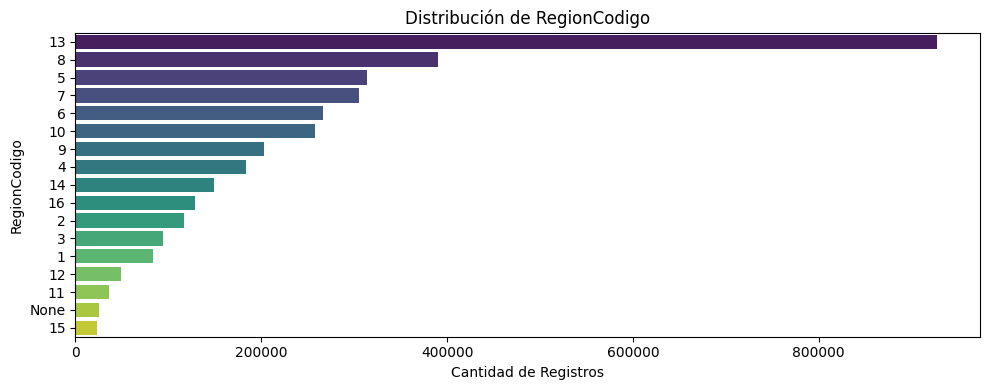

--------------------------------------------------
---- FRECUENCIAS: ComunaCodigo ----
ComunaCodigo
13110    59126
2101     54552
13401    52568
5101     49160
8301     46713
         ...  
8302      2760
5702      2628
5706      2556
5503      2508
8307      2400
Name: count, Length: 308, dtype: int64
Total de categorías únicas: 308

-> Gráfico omitido porque ComunaCodigo tiene demasiadas categorías (307).
--------------------------------------------------
---- FRECUENCIAS: ServicioSaludCodigo ----
ServicioSaludCodigo
16      305442
15      266695
10      236964
13      197707
14      190458
5       183812
7       155229
22      149560
21      138534
9       134001
17      128880
18      125927
3       116839
24      114639
6       111622
20      110334
12       97609
4        93754
19       85492
2        83199
11       76924
33       74091
23       69009
28       68738
29       64090
26       48768
8        40437
25       36100
None     25254
1        23084
Name: count, dtype: int64

<Figure size 1000x400 with 0 Axes>

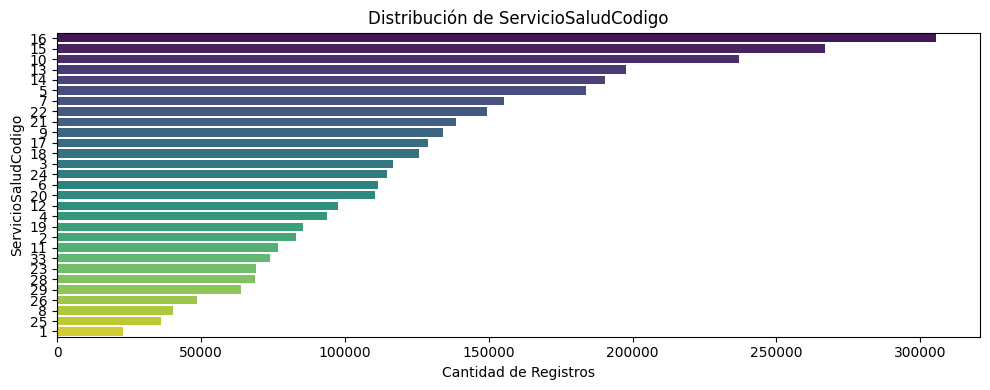

--------------------------------------------------
---- FRECUENCIAS: TipoEstablecimiento ----
TipoEstablecimiento
Servicio de Atención Primaria de Urgencia (SAPU)                         1343419
Hospital                                                                 1111185
Servicio de Urgencia Rural (SUR)                                          541086
Servicio de Atención Primaria de Urgencia de Alta Resolutividad (SAR)     507868
None                                                                       25254
Hospital                                                                   13184
Centro de Salud Familiar (CESFAM)                                           6725
Centro de Diagnóstico y Terapeútico (CDT)                                   4471
Name: count, dtype: int64
Total de categorías únicas: 8



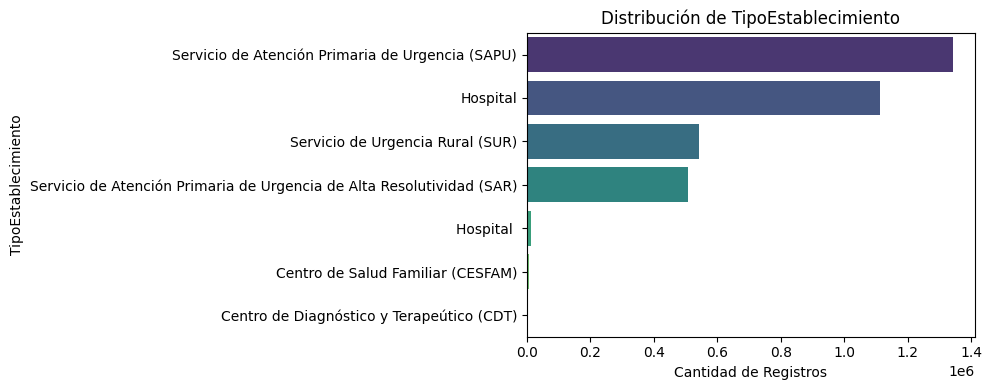

--------------------------------------------------
---- FRECUENCIAS: DependenciaAdministrativa ----
DependenciaAdministrativa
Municipal            2269457
Servicio de Salud    1203270
Municipal              28092
None                   25254
Delegados              20680
Otra Institución        6439
Name: count, dtype: int64
Total de categorías únicas: 6



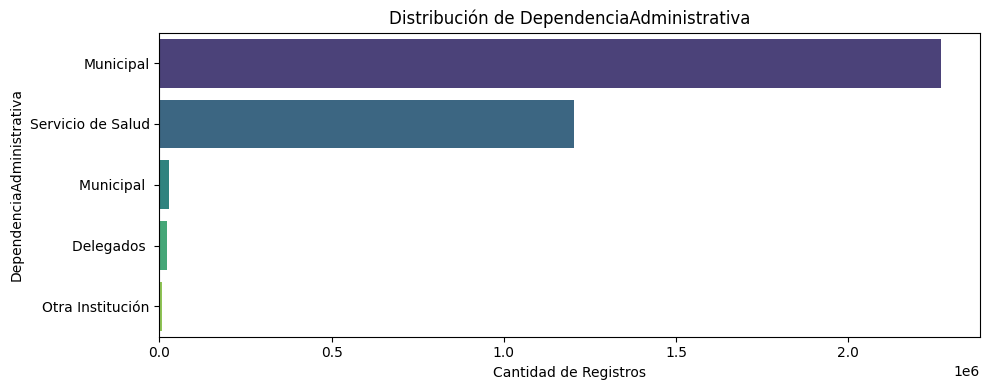

--------------------------------------------------
---- FRECUENCIAS: NivelAtencion ----
NivelAtencion
Primario      2991842
Terciario      522189
None            25254
Secundario      13907
Name: count, dtype: int64
Total de categorías únicas: 4



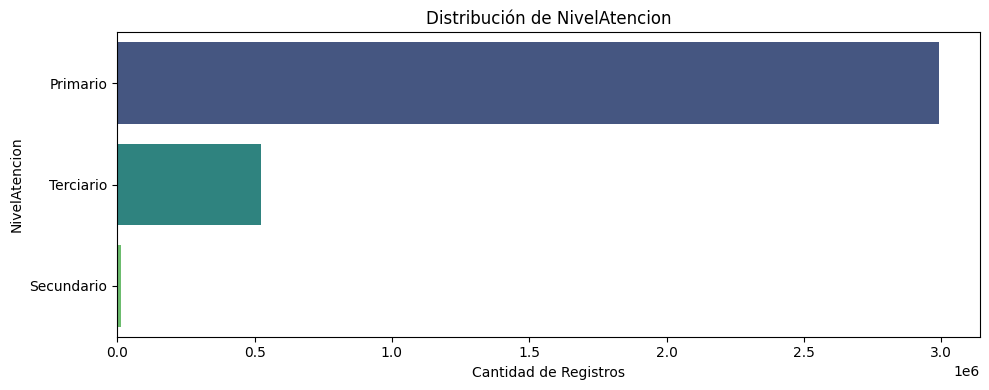

--------------------------------------------------
---- FRECUENCIAS: TipoUrgencia ----
TipoUrgencia
Urgencia Ambulatoria (SAPU)    1356658
Urgencia Hospitalaria (UEH)    1115354
Urgencia Ambulatoria (SUR)      541086
Urgencia ambulatoria (SAR)      456086
Urgencia Ambulatoria (SAR)       38543
None                             25254
Urgencia ambulatoria             10812
Urgencia Especializada            7791
Pendiente                         1224
No Aplica                          384
Name: count, dtype: int64
Total de categorías únicas: 10



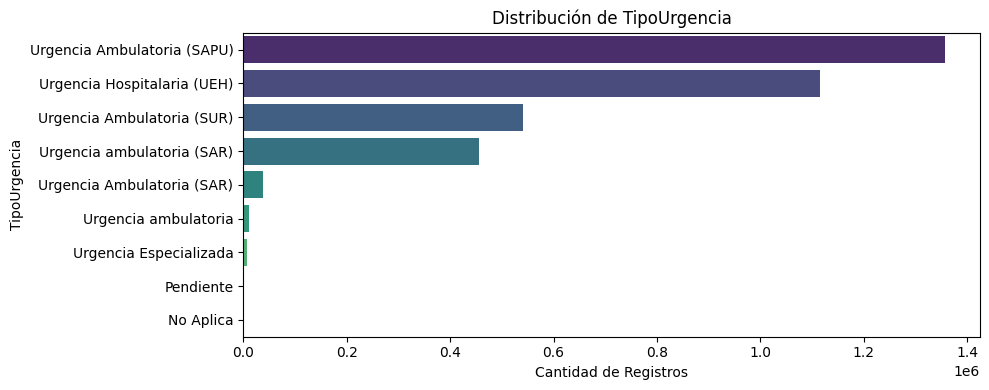

--------------------------------------------------
---- FRECUENCIAS: NivelComplejidad ----
NivelComplejidad
Baja Complejidad       2998410
Alta Complejidad        372826
Mediana Complejidad     153834
None                     25254
Completar                 2868
Name: count, dtype: int64
Total de categorías únicas: 5



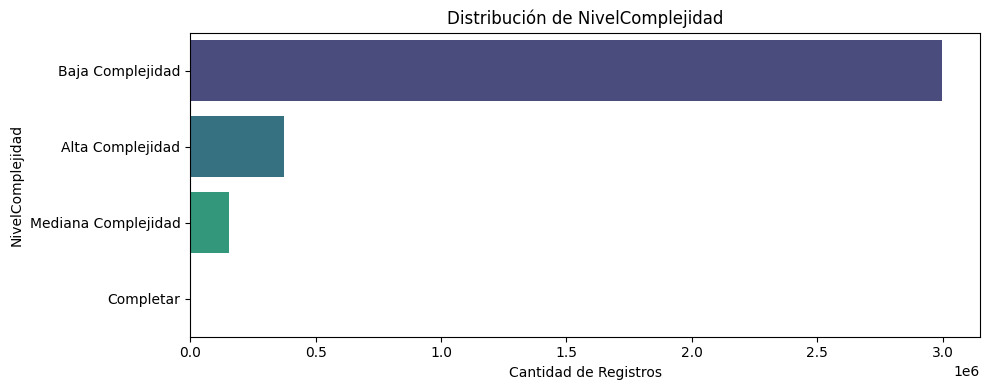

--------------------------------------------------
---- FRECUENCIAS: Anio ----
Anio
2025    401784
2024    384828
2023    381120
2022    379128
2021    377244
2020    325154
2019    192938
2026    190716
2018    187328
2017    186424
2016    185248
2015    184976
2014    176304
Name: count, dtype: int64
Total de categorías únicas: 13



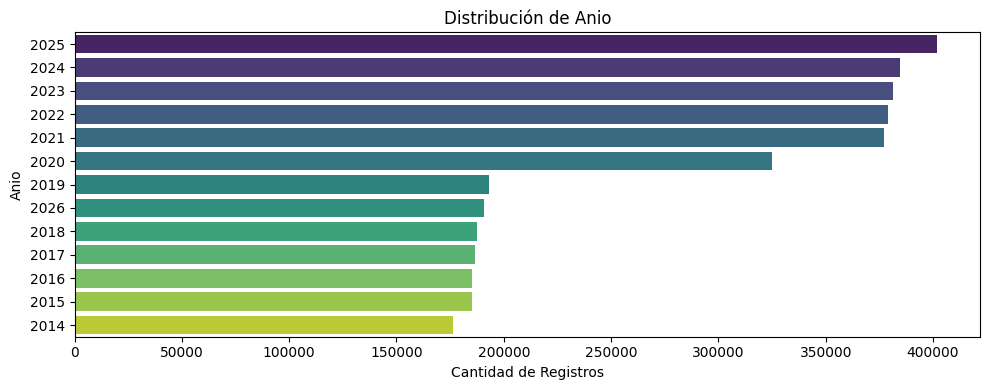

--------------------------------------------------
---- FRECUENCIAS: SemanaEstadistica ----
SemanaEstadistica
22    71716
23    71695
18    71457
13    71424
11    71381
21    71343
14    71286
12    71272
20    71231
19    71198
10    71166
15    71144
17    71138
9     71134
16    71095
24    70954
6     70864
7     70845
8     70823
1     70689
5     70116
2     69947
3     69914
4     69806
52    65191
49    65077
51    65076
50    65073
45    65027
46    65015
48    65012
47    64967
44    64816
40    64793
43    64781
42    64776
41    64755
36    64729
38    64723
39    64717
33    64707
31    64703
29    64673
32    64672
35    64670
37    64668
34    64659
27    64613
30    64573
28    64553
26    64349
25    64314
53    35872
Name: count, dtype: int64
Total de categorías únicas: 53

-> Gráfico omitido porque SemanaEstadistica tiene demasiadas categorías (53).
--------------------------------------------------
---- FRECUENCIAS: Causa ----
Causa
TOTAL CAUSA SISTEMA  RESPIRATORI

<Figure size 1000x400 with 0 Axes>

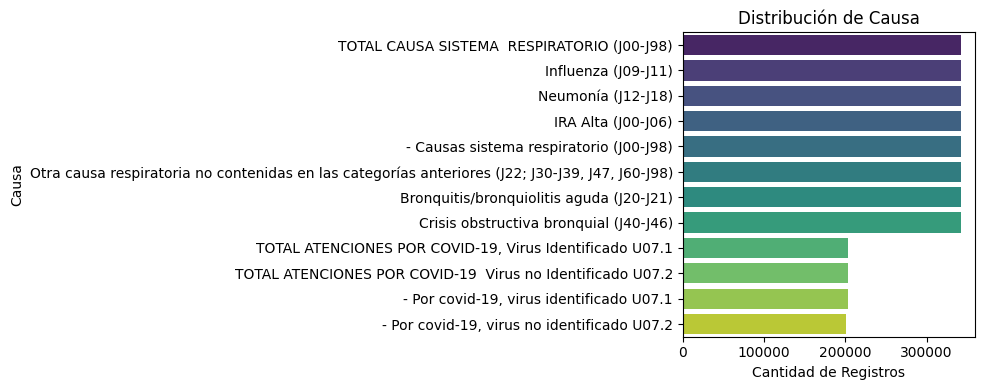

--------------------------------------------------
---- FRECUENCIAS: region ----
region
Metropolitana         920876
Ñuble                 387755
Valparaíso            311539
Maule                 303098
O'Higgins             264871
La Araucanía          255963
Bío Bío               200996
Coquimbo              182540
Aysén                 148468
Magallanes            127848
Antofagasta           115979
Atacama                93166
Tarapacá               82559
NaN                    50326
Los Lagos              48440
Los Ríos               35844
Arica y Parinacota     22924
Name: count, dtype: int64
Total de categorías únicas: 17



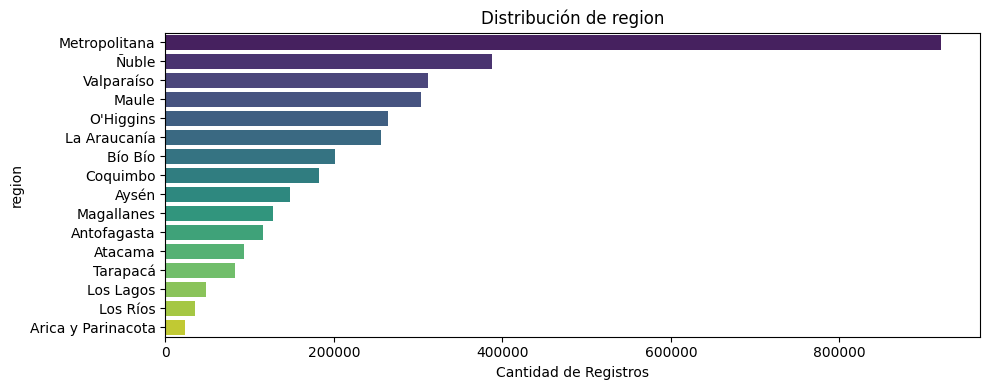

--------------------------------------------------


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas que queremos revisar
#cols_a_revisar = ['ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa']

# 1. Revisión de valores nulos
print("---- VALORES NULOS ----")
print(df.isnull().sum())
print("\n")

# 2. Iterar sobre las columnas para calcular frecuencias y graficarlas
for col in categoricas:
    print(f"---- FRECUENCIAS: {col} ----")
    # Ver cuántos datos hay de cada categoría
    frecuencias = df[col].value_counts(dropna=False)
    print(frecuencias)
    print(f"Total de categorías únicas: {df[col].nunique(dropna=False)}\n")
    
    # Gráficos si no son demasiadas categorías (para ServicioSaludCodigo puede que sean muchas)
    plt.figure(figsize=(10, 4))
    if df[col].nunique() < 50:
        sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribución de {col}')
        plt.xlabel('Cantidad de Registros')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print(f"-> Gráfico omitido porque {col} tiene demasiadas categorías ({df[col].nunique()}).")
    print("-" * 50)





In [82]:
# Eliminar todas las filas que contengan al menos un valor nulo (NaN) en cualquier columna
filas_previo = len(df)
print(f"Filas antes de eliminar nulos: {len(df)}")
df = df.dropna()
print(f"Filas después de eliminar nulos: {len(df)}")
print(f"Se eliminaron {filas_previo - len(df)} filas en total.")

Filas antes de eliminar nulos: 3553192
Filas después de eliminar nulos: 3502866
Se eliminaron 50326 filas en total.


In [83]:
#Comprobando si quedan nulos despues de la limpieza
import duckdb as db
con = db.connect()
con.register('df', df)
query = " select * from df where EstablecimientoCodigo is null"
result = con.execute(query).fetchdf()
print(result)
result.to_csv(f'../resultados/establecimientoNulo_DespuesLimpieza_{fecha_actual}.csv', index=False)

query = " select * from df where NivelComplejidad = '1.0'"
result = con.execute(query).fetchdf()
print(result)
result.to_csv(f'../resultados/NivelComplejidad123_{fecha_actual}.csv', index=False)

Empty DataFrame
Columns: [EstablecimientoCodigo, RegionCodigo, ComunaCodigo, ServicioSaludCodigo, TipoEstablecimiento, DependenciaAdministrativa, NivelAtencion, TipoUrgencia, NivelComplejidad, Anio, SemanaEstadistica, OrdenCausa, Causa, NumTotal, region, humedad_relativa_promedio_porcentaje, precipitacion_promedio_diario_mm, temp_promedio_semanal]
Index: []
Empty DataFrame
Columns: [EstablecimientoCodigo, RegionCodigo, ComunaCodigo, ServicioSaludCodigo, TipoEstablecimiento, DependenciaAdministrativa, NivelAtencion, TipoUrgencia, NivelComplejidad, Anio, SemanaEstadistica, OrdenCausa, Causa, NumTotal, region, humedad_relativa_promedio_porcentaje, precipitacion_promedio_diario_mm, temp_promedio_semanal]
Index: []


## Limpieza EstablecimientoCodigo, RegionCodigo, ComunaCodigo

In [84]:
print("--- REPORTE DE DATOS INVÁLIDOS ---")
columnas_interes = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo']
for col in columnas_interes:
    # 1. Hacemos una conversión "virtual" o temporal. 
    # Lo que no sea número se vuelve nulo temporalmente, pero el 'df' original queda intacto.
    simulacion = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Comparamos: Buscamos filas que originalmente NO estaban vacías, 
    # pero que fallaron en la simulación matemática.
    datos_malos = df[(df[col].notnull()) & (simulacion.isnull())]
    
    # 3. Mostramos los resultados
    cantidad_errores = len(datos_malos)
    
    if cantidad_errores > 0:
        print(f"\n⚠️ PELIGRO: La columna '{col}' tiene {cantidad_errores} datos inválidos (no son números).")
        print("Aquí tienes los primeros 5 ejemplos de los datos problemáticos para que los veas:")
        # display() es perfecto en Jupyter para mostrar tablitas bonitas
        display(datos_malos[[col]].head()) 
    else:
        print(f"\n✅ La columna '{col}' está limpia. Todos sus textos son números válidos.")

--- REPORTE DE DATOS INVÁLIDOS ---

✅ La columna 'EstablecimientoCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'RegionCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'ComunaCodigo' está limpia. Todos sus textos son números válidos.


--- 

## Limpieza Anio, NivelComplejidad

In [85]:
from datetime import datetime

df['NC_Original'] = df['NivelComplejidad'].astype(str)


df['NivelComplejidad'] = df['NivelComplejidad'].astype(str).str.strip().str.title()

mapeo_rescate = {
    'Baja': 'Baja Complejidad', 'Bajacomplejidad': 'Baja Complejidad',
    'Mediana': 'Mediana Complejidad', 'Medianacomplejidad': 'Mediana Complejidad',
    'Alta': 'Alta Complejidad', 'Altacomplejidad': 'Alta Complejidad',
    'N/A': 'No Aplica', 'Na': 'No Aplica', 'Noaplica': 'No Aplica'
}
df['NivelComplejidad'] = df['NivelComplejidad'].replace(mapeo_rescate)

categorias_validas = ['Alta Complejidad', 'Mediana Complejidad', 'Baja Complejidad', 'No Aplica', 'Pendiente']
df.loc[~df['NivelComplejidad'].isin(categorias_validas), 'NivelComplejidad'] = 'Pendiente'

anio_actual = datetime.now().year

df = df.dropna(subset=['Anio'])
df['Anio'] = df['Anio'].astype(int)
df = df[(df['Anio'] >= 2014) & (df['Anio'] <= anio_actual)]

mask_cambio = df['NC_Original'] != df['NivelComplejidad']
reporte_cambios = df[mask_cambio].groupby(['NC_Original', 'NivelComplejidad']).size().reset_index(name='Casos')

#print(f"Registros eliminados (por año inválido): {filas_iniciales - len(df) if 'filas_iniciales' in locals() else 'revisar'}")
print("\nDetalle de correcciones en Nivel de Complejidad:")
print(reporte_cambios.sort_values('Casos', ascending=False))

df = df.drop(columns=['NC_Original'])


Detalle de correcciones en Nivel de Complejidad:
  NC_Original NivelComplejidad  Casos
0   Completar        Pendiente   2844


In [86]:
def limpiar_datos_urgencia(df):
    print("Limpieza de NivelAtencion y TipoUrgencia...")
    
    df_limpio = df.copy()
    
    columnas_objetivo = ['NivelAtencion', 'TipoUrgencia']
    
    print("Nulos antes de limpiar:")
    print(df_limpio[columnas_objetivo].isnull().sum())
    
    # Limpieza
    for col in columnas_objetivo:
        # Rellenar nulos
        #df_limpio[col] = df_limpio[col].fillna('DESCONOCIDO')
        
        # Pasar a mayúsculas y quitar espacios extra
        df_limpio[col] = df_limpio[col].astype(str).str.strip().str.upper()

    # Nulos finales
    print("\nNulos después de limpiar:")
    print(df_limpio[columnas_objetivo].isnull().sum())
    print("-" * 50)
    
    return df_limpio

#df = limpiar_datos_urgencia(df)
df.head().to_csv(f'../resultados/limpieza_rafa_{fecha_actual}.csv', index=False)

## Estandarizacion Causa

In [87]:
df['Causa_Busqueda'] = df['Causa'].str.lower().str.replace(r'^- ', '', regex=True).str.strip()

mapeo_codigos = {
    'j00-j06': 'IRA alta (J00-J06)',
    'j09-j11': 'Influenza (J09-J11)',
    'j12-j18': 'Neumonía (J12-J18)',
    'j20-j21': 'Bronquitis/Bronquiolitis aguda (J20-J21)',
    'j40-j46': 'Crisis obstructiva bronquial (J40-J46)',
    'j22': 'Otra causa respiratoria (J22, J30-J39, J47, J60-J98)',
    'u07.1': 'COVID-19, virus identificado (U07.1)',
    'u07.2': 'COVID-19, virus no identificado (U07.2)'
}

def clasificar(texto):
    if 'total' in texto:
        return 'DESCARTAR'
    for codigo, nombre_oficial in mapeo_codigos.items():
        if codigo in texto:
            return nombre_oficial
    return 'DESCARTAR'

df['Causa_Final'] = df['Causa_Busqueda'].apply(clasificar)

# 3. Quedarnos solo con los datos limpios
df = df[df['Causa_Final'] != 'DESCARTAR'].copy()

# 4. Limpieza final de columnas (quitamos la auxiliar de búsqueda y renombramos)
df = df.drop(columns=['Causa', 'Causa_Busqueda'])
df = df.rename(columns={'Causa_Final': 'Causa'})

## Analisis Atipicos de NumTotal

1. Rango de Semanas: 1 a 53
   -> Registros fuera de rango (1-53): 0
2. Rango de OrdenCausa: 4 a 35
   -> Verificación: OK

----------------------------------------

3. Resumen de Límites y Cantidad de Outliers por Causa:
                                                    Limite_Sup  Cant_Outliers
Causa                                                                        
Bronquitis/Bronquiolitis aguda (J20-J21)                  76.5        18520.0
COVID-19, virus identificado (U07.1)                       0.0        10517.0
COVID-19, virus no identificado (U07.2)                    0.0         8820.0
Crisis obstructiva bronquial (J40-J46)                    21.0        25215.0
IRA alta (J00-J06)                                       358.5        10386.0
Influenza (J09-J11)                                        5.0        45092.0
Neumonía (J12-J18)                                        18.5        27435.0
Otra causa respiratoria (J22, J30-J39, J47, J60...        26.0        41909.

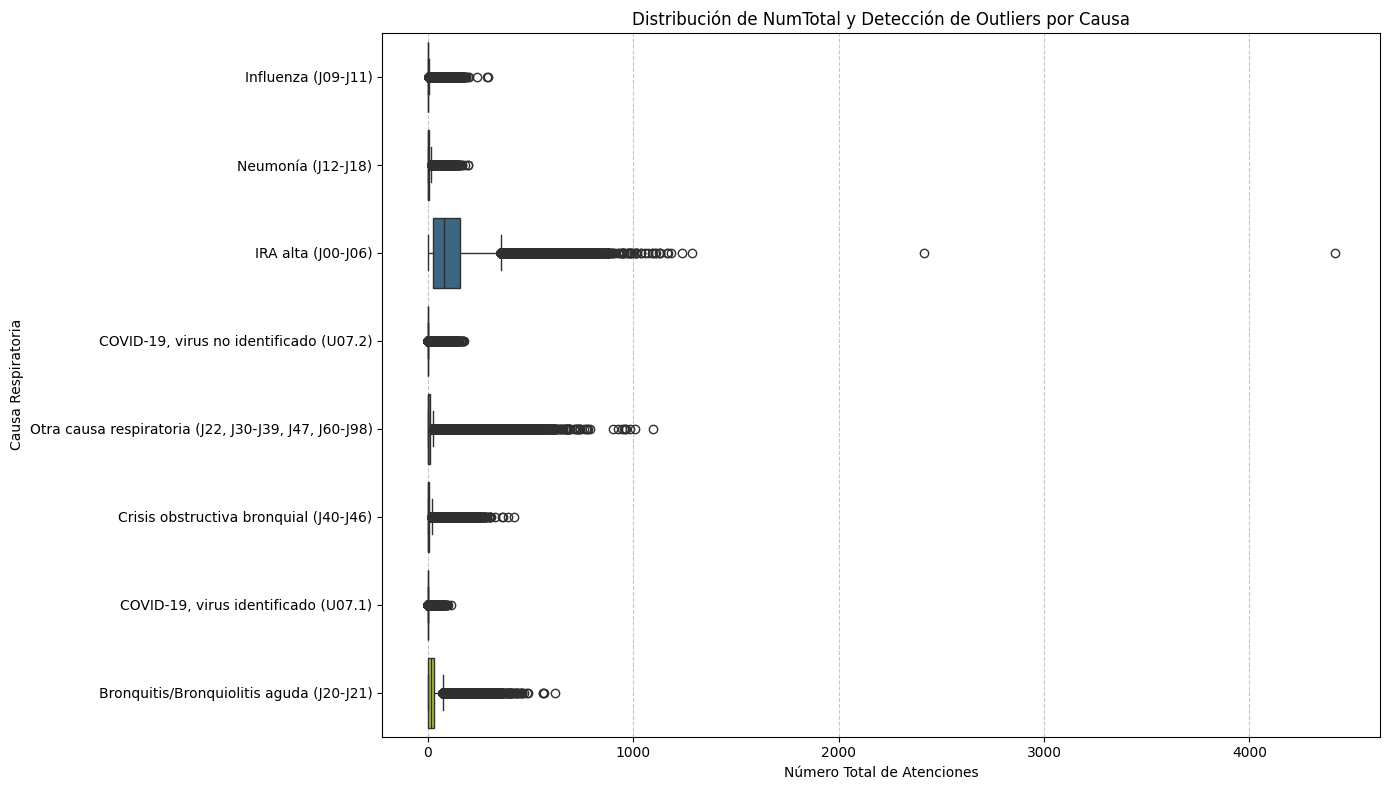


4. TOP 5 REGISTROS MÁS EXTREMOS (VALORES MÁS ALTOS):
         Anio  SemanaEstadistica               Causa  NumTotal
1985138  2022                 50  IRA alta (J00-J06)      4415
110494   2015                 43  IRA alta (J00-J06)      2415
3551088  2017                 11  IRA alta (J00-J06)      1285
227586   2023                 20  IRA alta (J00-J06)      1236
1090283  2022                  6  IRA alta (J00-J06)      1183


In [88]:
# ==================================================
# 1. VALIDACIÓN DE RANGOS LÓGICOS (NUEVO)
# ==================================================
# Chequeo de Semanas (1-53)
df['SemanaEstadistica'] = df['SemanaEstadistica'].astype(int)
semanas_invalidas = df[(df['SemanaEstadistica'] < 1) | (df['SemanaEstadistica'] > 53)]
min_sem = df['SemanaEstadistica'].min()
max_sem = df['SemanaEstadistica'].max()

print(f"1. Rango de Semanas: {min_sem} a {max_sem}")
print(f"   -> Registros fuera de rango (1-53): {len(semanas_invalidas)}")

# Chequeo de OrdenCausa (3-35 según tus datos)
min_ord = df['OrdenCausa'].min()
max_ord = df['OrdenCausa'].max()
print(f"2. Rango de OrdenCausa: {min_ord} a {max_ord}")
print(f"   -> Verificación: {'OK' if min_ord >= 3 and max_ord <= 35 else 'REVISAR RANGOS'}")

print("\n" + "-"*40 + "\n")

# ==================================================
# 2. ANÁLISIS DE OUTLIERS (IQR)
# ==================================================
def detect_outliers_iqr(group):
    Q1 = group['NumTotal'].quantile(0.25)
    Q3 = group['NumTotal'].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    outliers = group[group['NumTotal'] > limite_superior]
    return pd.Series([limite_superior, len(outliers)], index=['Limite_Sup', 'Cant_Outliers'])

outliers_por_causa = df.groupby('Causa').apply(detect_outliers_iqr)

print("3. Resumen de Límites y Cantidad de Outliers por Causa:")
print(outliers_por_causa)

# ==================================================
# 3. VISUALIZACIÓN Y REGISTROS EXTREMOS
# ==================================================
# Gráfico Boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='NumTotal', y='Causa', palette='viridis')
plt.title('Distribución de NumTotal y Detección de Outliers por Causa')
plt.xlabel('Número Total de Atenciones')
plt.ylabel('Causa Respiratoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n4. TOP 5 REGISTROS MÁS EXTREMOS (VALORES MÁS ALTOS):")
print(df.sort_values(by='NumTotal', ascending=False)[['Anio', 'SemanaEstadistica', 'Causa', 'NumTotal']].head())

df.head(200).to_csv(f'../resultados/LimpiezaRenatoFinalAhoraSiQueSi_{fecha_actual}.csv', index=False)

## Matrices de correlacion

### Numerica

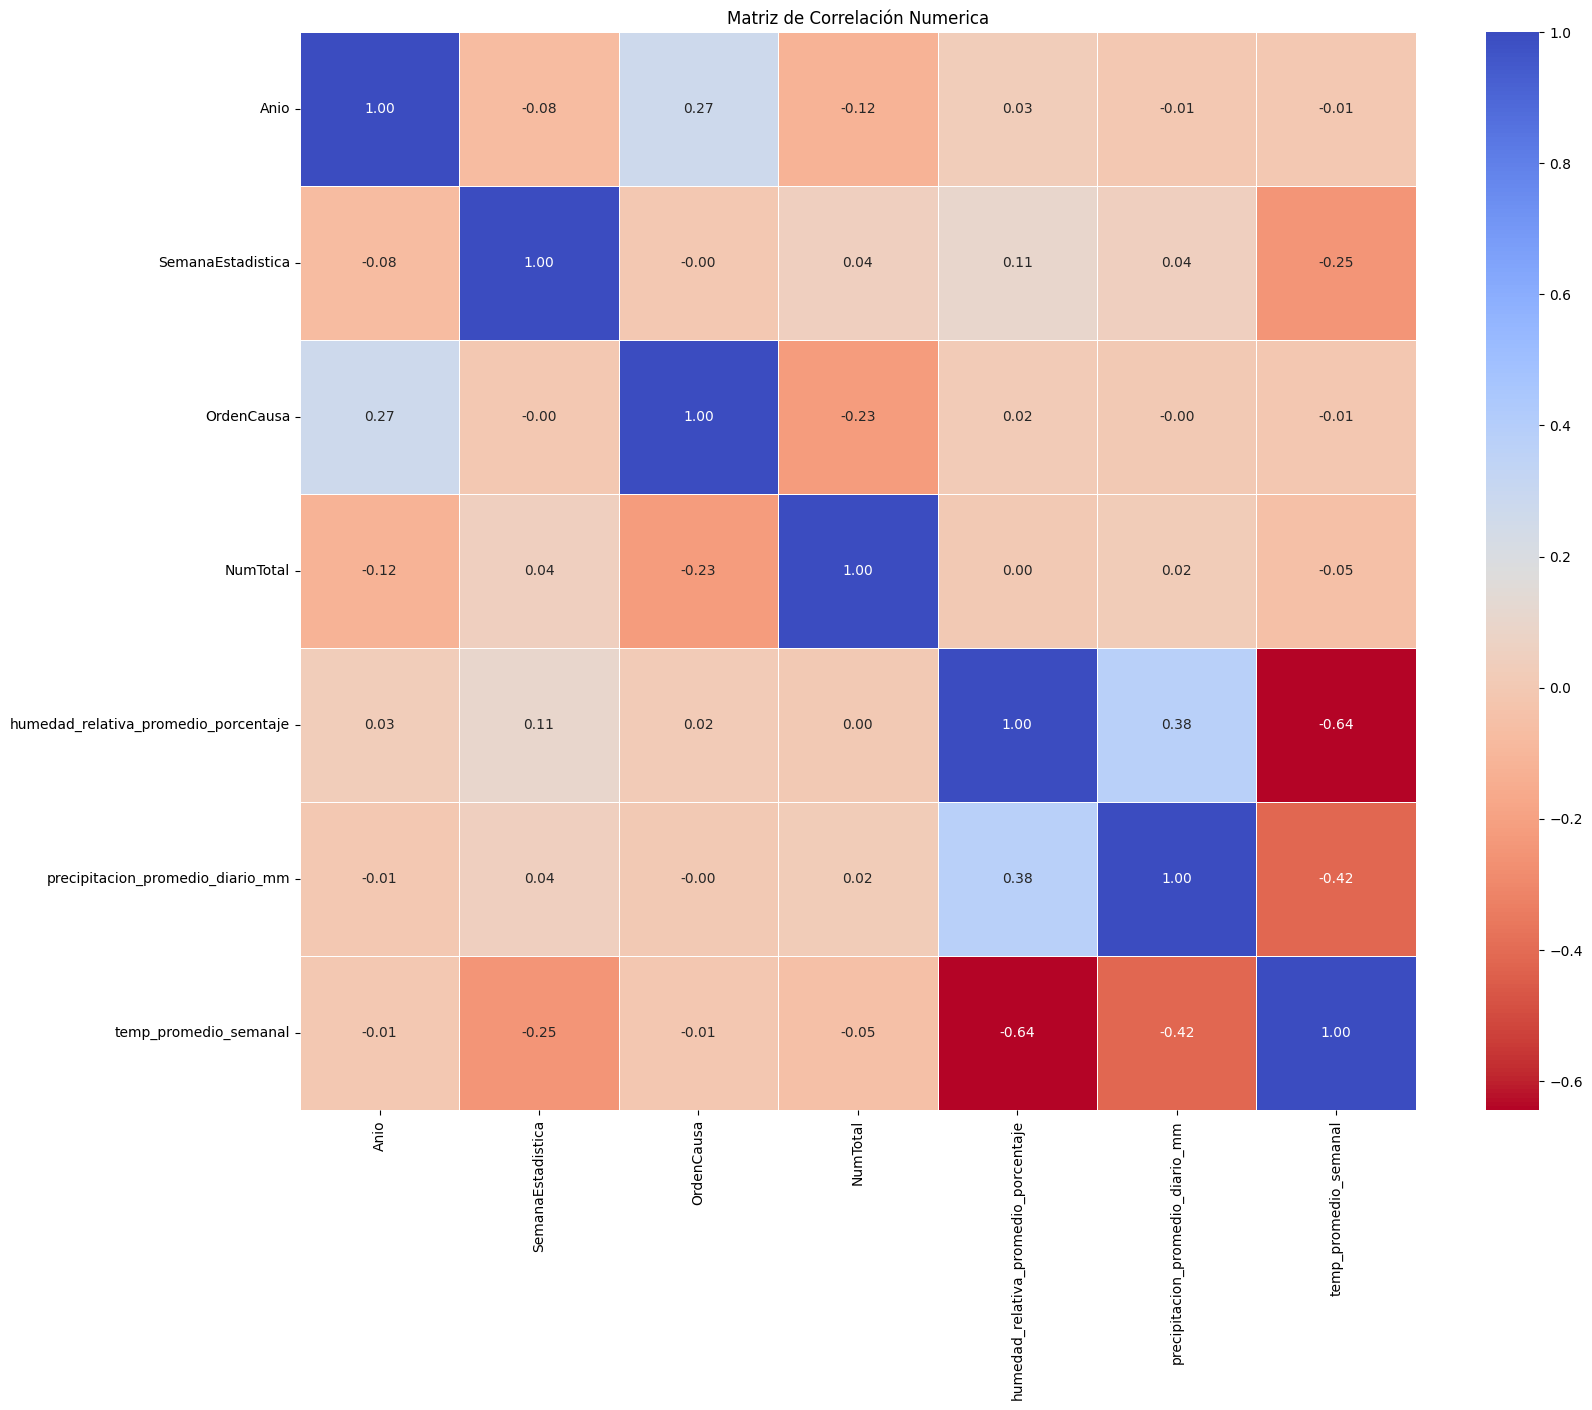

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas y booleanas (One-Hot) para la correlación
numerica_df = df.select_dtypes(include=['number', 'bool'])

# Generar la matriz de correlación (Ajustamos el tamaño para que quepan más variables)
plt.figure(figsize=(18, 14))
sns.heatmap(numerica_df.corr(), annot=True, cmap='coolwarm_r', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación Numerica')
plt.savefig(f'../resultados/matriz_correlacion_numerica_{fecha_actual}.png', dpi=300, bbox_inches='tight')  # Guardar la figura con alta resolución
plt.show()

### Categorica

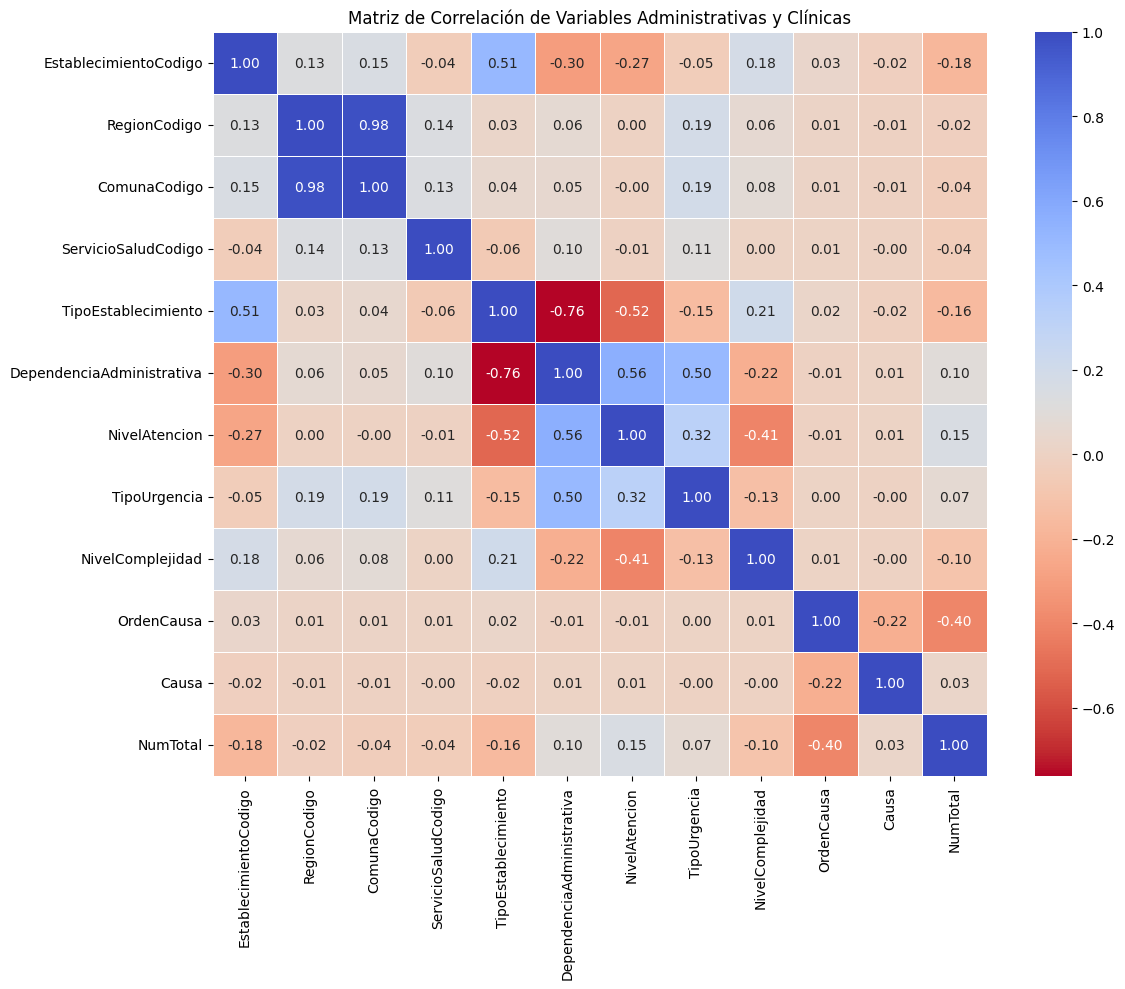

In [90]:
vars_matriz = [
    'EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 
    'ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa', 
    'NivelAtencion', 'TipoUrgencia', 'NivelComplejidad', 
    'OrdenCausa', 'Causa', 'NumTotal' # Agrego NumTotal para que la matriz tenga una meta
]

# 3. Preprocesamiento: Convertir categorías (strings) a números para poder correlacionar
df_corr = df[vars_matriz].copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# 4. Cálculo de la Matriz de Correlación (Spearman es mejor para categorías/orden)
corr_matrix = df_corr.corr(method='spearman')

# 5. Visualización con un Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Administrativas y Clínicas')
plt.tight_layout()
plt.savefig(f'../resultados/matriz_correlacion_categorica_{fecha_actual}.png', dpi=300, bbox_inches='tight')  # Guardar la figura con alta resolución
plt.show()

# 3. Explore

### 2. Tratamiento de Variables Redundantes (Glosas vs Códigos)
Eliminamos las columnas de nombre ("Glosa") ya que contienen información redundante que aportaría colinealidad. Los códigos se forzan a tipo categórico (texto) para que no creen ponderaciones falsas en la correlación.

In [91]:
# Eliminar Glosas (nombres irrelevantes / colineales al código)
cols_glosa = ['EstablecimientoGlosa', 'RegionGlosa', 'ComunaGlosa', 'ServicioSaludGlosa']
df = df.drop(columns=cols_glosa, errors='ignore')

# Asegurar que los ID/Códigos sean texto y no números continuos
cols_codigo = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 'ServicioSaludCodigo']
for col_cod in cols_codigo:
    if col_cod in df.columns:
        df[col_cod] = df[col_cod].astype(str)

print("Columnas de código categorizadas correctamente. Columnas 'Glosa' eliminadas.")

Columnas de código categorizadas correctamente. Columnas 'Glosa' eliminadas.


### 3. Transformación de Variables Ordinales
Asignamos valores numéricos según su jerarquía intrínseca. 
- *NivelAtencion*: Primario (1), Secundario (2), Terciario (3)
- *NivelComplejidad*: Baja (1), Mediana (2), Alta (3)

In [92]:
# Diccionarios de mapeo para variables con jerarquía
mapa_atencion = {
    'PRIMARIO': 1,
    'SECUNDARIO': 2,
    'TERCIARIO': 3
}

mapa_complejidad = {
    'Baja Complejidad': 1,
    'Mediana Complejidad': 2,
    'Alta Complejidad': 3
}

# Aplicar los mapeos
if 'NivelAtencion' in df.columns:
    df['NivelAtencion'] = df['NivelAtencion'].map(mapa_atencion)
    
if 'NivelComplejidad' in df.columns:
    df['NivelComplejidad'] = df['NivelComplejidad'].map(mapa_complejidad)

print("Variables ordinales transformadas:")
print(df[['NivelAtencion', 'NivelComplejidad']].head(3))

Variables ordinales transformadas:
   NivelAtencion  NivelComplejidad
3            NaN               1.0
4            NaN               1.0
5            NaN               3.0


### 4. Transformación de Variables Nominales (One-Hot Encoding)
Para aquellas categorías que no tienen orden matemático (`TipoEstablecimiento`, `DependenciaAdministrativa`, `TipoUrgencia`, `Causa`).
Para la columna `Causa`, agruparemos las causas de menor frecuencia bajo la categoría "Otras" para evitar una explosión de columnas dispersas.

In [93]:
# Tratamiento de columna 'Causa' (agrupar causas poco comunes en 'Otras')
if 'Causa' in df.columns:
    # Determinamos el límite: nos quedaremos solo con causas que representen al menos el ~5% de los datos (o el top 5)
    frecuencias_causas = df['Causa'].value_counts(normalize=True)
    # Por ejemplo, conservamos causas que superen el 3% de los registros
    causas_importantes = frecuencias_causas[frecuencias_causas > 0.03].index
    
    # Reemplazar con 'Otras_Causas' a los que no estén en `causas_importantes`
    df['Causa'] = df['Causa'].apply(lambda x: x if x in causas_importantes else 'Otras_Causas')

# Aplicar One-Hot Encoding
columnas_nominales = ['TipoEstablecimiento', 'DependenciaAdministrativa', 'TipoUrgencia', 'Causa']
# Filtramos para asegurar que las columnas existan en el df actual antes de get_dummies
columnas_nominales_validas = [col for col in columnas_nominales if col in df.columns]

# Generamos las columnas One-Hot. Con drop_first=True evitamos mínima colinealidad extra si prefieres. 
# Dejaremos drop_first=False para fácil interpretabilidad en la correlación.
df = pd.get_dummies(df, columns=columnas_nominales_validas, drop_first=False)

print(f"Dimensiones del DataFrame después de One-Hot Encoding: {df.shape}")

Dimensiones del DataFrame después de One-Hot Encoding: (2427387, 43)


# Agregar variables exogenas

## Temperatura promedio por region | año | semana 

In [94]:
#fecha_actual = datetime.now().strftime("%Y-%m-%d-%H%M%S")

df.head(100).to_csv(f'../resultados/DatosFormatoNumerico_{fecha_actual}.csv', index=False)

In [95]:


df.to_parquet(f'./dataset_limpios/at_urg_respiratorio_limpio_{fecha_actual}.parquet', index=False, engine='fastparquet')

## Análisis de Series Temporales (Estacionalidad, Tendencia, Estacionariedad)
A continuación, cargaremos los datos limpios y crearemos una fecha a partir de `Anio` y `SemanaEstadistica`. Luego, analizaremos la serie temporal de `NumTotal`.

In [96]:
%pip install pandas numpy matplotlib statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


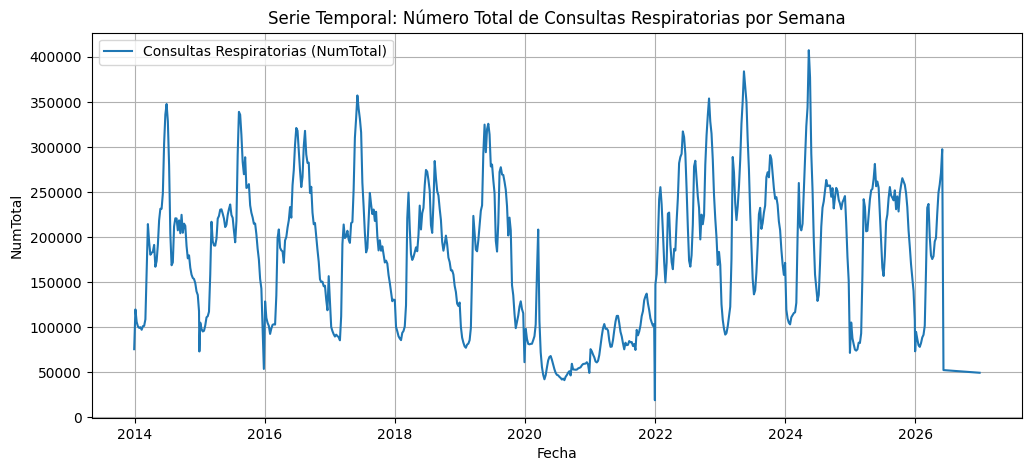

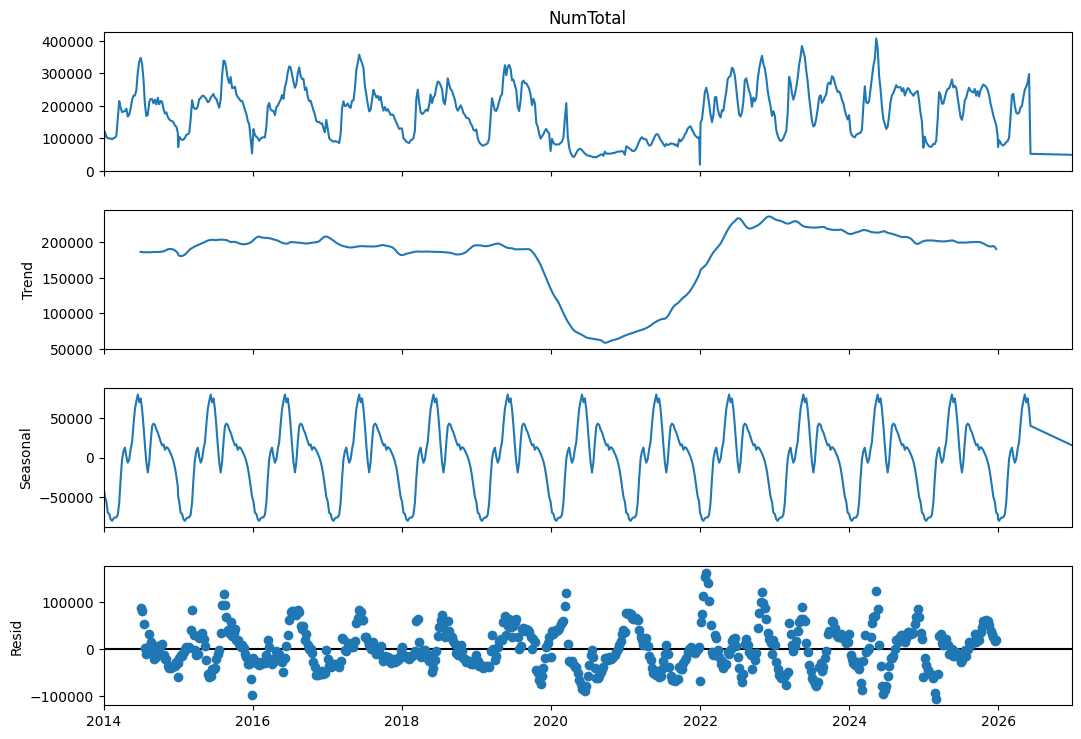

--- Prueba ADF (Augmented Dickey-Fuller) ---
Estadístico ADF: -5.734455275544158
p-value: 6.486731267749113e-07
Valores Críticos:
   1%: -3.440419374623044
   5%: -2.865983079837035
   10%: -2.5691361169972526

Conclusión: Rechazamos la hipótesis nula. La serie es ESTACIONARIA.


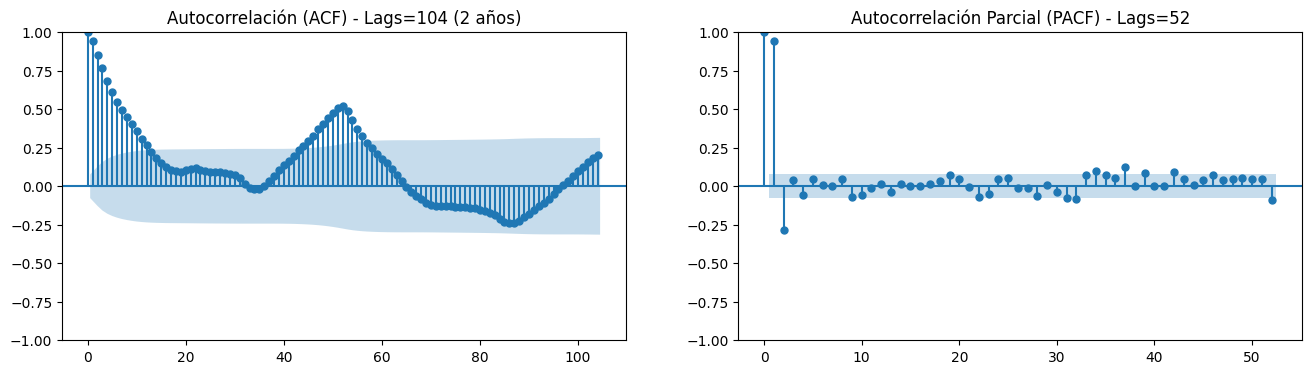

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime

# 1. Cargar el dataset limpio
df = pd.read_parquet(f'dataset_limpios/dataset_base_mas_exogenas_{fecha_actual}.parquet')

# 2. Crear una columna de fecha a partir de Anio y SemanaEstadistica
# Usamos el lunes de cada semana como representación de la fecha
def get_date_from_iso_week(year, week):
    # Formato '%G-W%V-%u' -> %G año ISO, %V semana ISO, %u día de la semana (1-7)
    date_str = f'{year}-W{week:02d}-1' 
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        # Algunos años pueden tener 53 semanas, si hay error usamos el ultimo dia del año
        return datetime(year, 12, 31)

df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

# Agrupar por fecha y sumar el NumTotal
ts_df = df.groupby('Fecha')['NumTotal'].sum().reset_index()
ts_df.set_index('Fecha', inplace=True)
ts_df.sort_index(inplace=True)

# 3. Visualización de la Serie Temporal
plt.figure(figsize=(12, 5))
plt.plot(ts_df.index, ts_df['NumTotal'], label='Consultas Respiratorias (NumTotal)')
plt.title('Serie Temporal: Número Total de Consultas Respiratorias por Semana')
plt.xlabel('Fecha')
plt.ylabel('NumTotal')
plt.legend()
plt.grid(True)
plt.show()

# 4. Descomposición de la serie (Tendencia, Estacionalidad, Ruido)
# Asumimos una estacionalidad anual. Al tener datos semanales, el periodo es 52
decomposition = seasonal_decompose(ts_df['NumTotal'], model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 5. Prueba de Estacionariedad (Test de Dickey-Fuller Aumentado - ADF)
def adf_test(series):
    result = adfuller(series.dropna())
    print('--- Prueba ADF (Augmented Dickey-Fuller) ---')
    print('Estadístico ADF:', result[0])
    print('p-value:', result[1])
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    if result[1] <= 0.05:
        print("\nConclusión: Rechazamos la hipótesis nula. La serie es ESTACIONARIA.")
    else:
        print("\nConclusión: No podemos rechazar la hipótesis nula. La serie NO ES ESTACIONARIA.")

adf_test(ts_df['NumTotal'])

# 6. Gráficos ACF y PACF para determinar parámetros pdq de modelos ARIMA/SARIMA
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts_df['NumTotal'].dropna(), ax=axes[0], lags=104, title='Autocorrelación (ACF) - Lags=104 (2 años)')
plot_pacf(ts_df['NumTotal'].dropna(), ax=axes[1], lags=52, title='Autocorrelación Parcial (PACF) - Lags=52')
plt.show()


# Modelado de Series Temporales: SARIMA

En base al análisis exploratorio previo (test ADF estacionario, pero con fuerte estacionalidad anual en enfermedades respiratorias), aplicaremos el modelo **SARIMA** (Seasonal Autoregressive Integrated Moving Average).

Separaremos la serie temporal dejando el último año (52 semanas) como conjunto de prueba (test set) para evaluar qué tan bien el modelo puede predecir "el futuro" comparado con los datos reales que ya tenemos.

In [98]:
%pip install pandas numpy matplotlib statsmodels scikit-learn pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime

# 1. Cargar el dataset limpio
df = pd.read_parquet(f'dataset_limpios/dataset_base_mas_exogenas_{fecha_actual}.parquet')

# 2. Crear columna Fecha
def get_date_from_iso_week(year, week):
    date_str = f'{year}-W{week:02d}-1'
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        return datetime(year, 12, 31)

df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

# --- FIX: Agregar exógenas al groupby ---
variables_exogenas = [
    'temp_promedio_semanal',
    'precipitacion_promedio_diario_mm',
    'humedad_relativa_promedio_porcentaje'
]

# NumTotal se suma, las exógenas se promedian por semana
ts_num = df.groupby('Fecha')['NumTotal'].sum()
ts_exog = df.groupby('Fecha')[variables_exogenas].mean()

# Unir en un solo DataFrame
ts_df = pd.concat([ts_num, ts_exog], axis=1)
ts_df.sort_index(inplace=True)

# Asignar frecuencia semanal explícita para evitar advertencias de Statsmodels
ts_df = ts_df.asfreq('W-MON')
# Rellenar valores nulos (si hubiera semanas omitidas) con el método ffill (forward fill) o interpolación lineal
ts_df['NumTotal'] = ts_df['NumTotal'].interpolate(method='linear')

print("Datos preparados. Frecuencia de la serie indexada:\n", ts_df.head(2))

Datos preparados. Frecuencia de la serie indexada:
             NumTotal  temp_promedio_semanal  precipitacion_promedio_diario_mm  \
Fecha                                                                           
2013-12-30   75754.0              19.636302                          0.229927   
2014-01-06  119835.0              20.675908                          0.367845   

            humedad_relativa_promedio_porcentaje  
Fecha                                             
2013-12-30                             53.958637  
2014-01-06                             58.071283  


In [100]:
# 2. Dividir los datos en Entrenamiento (Train) y Prueba (Test)
# Entrenar desde el 2022 hasta el 2025, y testear solo con el año 2026.

# Definir el mes y año que quieres predecir
año_objetivo = 2019
mes_objetivo = 5  # Mayo, por ejemplo

# El set de prueba será SOLO ese año y ese mes
test = ts_df[(ts_df.index.year == año_objetivo) & (ts_df.index.month == mes_objetivo)]

# El entrenamiento será TODO el historial disponible justo antes de que empiece el test
train = ts_df[ts_df.index < test.index.min()]

test_size = len(test)

print(f"Fechas de Entrenamiento: desde {train.index.min().date()} hasta {train.index.max().date()}")
print(f"Fechas de Prueba (Test): desde {test.index.min().date()} hasta {test.index.max().date()}")
print(f"Semanas en entrenamiento: {len(train)}")
print(f"Semanas en prueba (test): {test_size}")

Fechas de Entrenamiento: desde 2013-12-30 hasta 2019-04-29
Fechas de Prueba (Test): desde 2019-05-06 hasta 2019-05-27
Semanas en entrenamiento: 279
Semanas en prueba (test): 4


In [107]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- 1. Definir la lista de tus variables exógenas ---
variables_exogenas = ['temp_promedio_semanal',
                      #'radiacion_solar_media_MJ_m2',
                      'precipitacion_promedio_diario_mm',
                      'humedad_relativa_promedio_porcentaje'] 

fechas_a_evaluar = pd.date_range(start='2019-01-01', end='2019-04-01', freq='MS')
resultados_predicciones = {}

for fecha in fechas_a_evaluar:
    año_objetivo = fecha.year
    mes_objetivo = fecha.month
    periodo_str = fecha.strftime('%Y-%m')
    
    print(f"\n{'='*40}")
    print(f"Evaluando mes: {periodo_str}")
    
    # --- DIVISIÓN DE DATOS (Target y Exógenas) ---
    test = ts_df[(ts_df.index.year == año_objetivo) & (ts_df.index.month == mes_objetivo)]
    
    if len(test) == 0:
        continue
        
    train = ts_df[ts_df.index < test.index.min()]
    
    # Separamos las variables exógenas de Train y Test
    exog_train = train[variables_exogenas].fillna(method='ffill') 
    exog_test = test[variables_exogenas].fillna(method='ffill')
    
    print(f"Entrenando con {len(train)} semanas, prediciendo {len(test)} semanas...")
    
    # --- ENTRENAMIENTO DEL MODELO CON EXÓGENAS ---
    model = SARIMAX(train['NumTotal'], 
                    exog=exog_train,  
                    order=(0, 0, 1),
                    seasonal_order=(0, 1, 0, 52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    results = model.fit(disp=False) 
    
    # --- PREDICCIÓN CON EXÓGENAS E INTERVALOS ---
    # CAMBIO AQUÍ: Usamos get_forecast para sacar la media y el intervalo
    forecast_obj = results.get_forecast(steps=len(test), exog=exog_test) 
    pred_mean = forecast_obj.predicted_mean
    pred_ci = forecast_obj.conf_int()
    
    # --- GUARDAR RESULTADOS ---
    resultados_predicciones[periodo_str] = {
        'test_real': test['NumTotal'],
        'prediccion': pred_mean,
        'limite_inferior': pred_ci.iloc[:, 0], # Límite inferior del intervalo
        'limite_superior': pred_ci.iloc[:, 1]  # Límite superior del intervalo
    }
    
print("\n¡Ejecución de múltiples modelos con variables exógenas finalizada!")


Evaluando mes: 2019-01
Entrenando con 262 semanas, prediciendo 4 semanas...

Evaluando mes: 2019-02
Entrenando con 266 semanas, prediciendo 4 semanas...

Evaluando mes: 2019-03
Entrenando con 270 semanas, prediciendo 4 semanas...

Evaluando mes: 2019-04
Entrenando con 274 semanas, prediciendo 5 semanas...

¡Ejecución de múltiples modelos con variables exógenas finalizada!


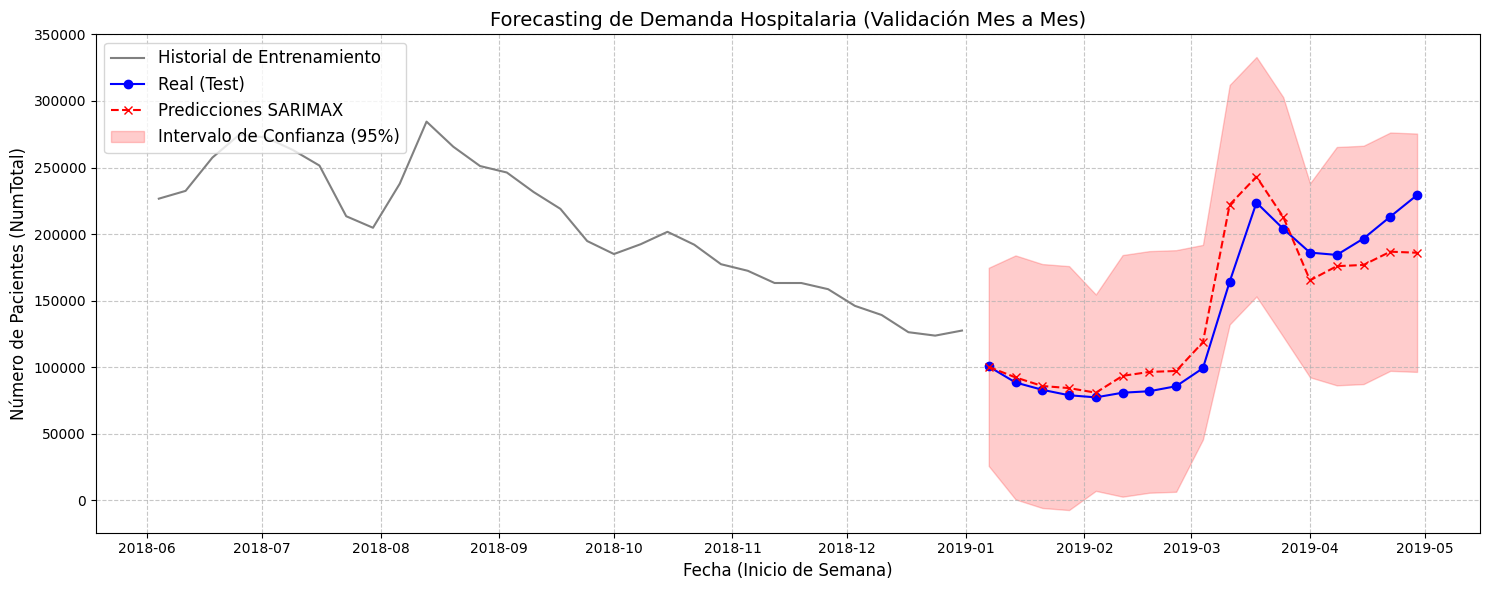

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraer y unir todos los meses del diccionario
lista_predicciones = []
lista_reales = []
lista_limite_inf = []
lista_limite_sup = []

for periodo, datos in resultados_predicciones.items():
    lista_predicciones.append(datos['prediccion'])
    lista_reales.append(datos['test_real'])
    lista_limite_inf.append(datos['limite_inferior'])
    lista_limite_sup.append(datos['limite_superior'])

# Concatenamos las listas para tener una sola Serie de tiempo continua
predicciones_continuas = pd.concat(lista_predicciones)
reales_continuas = pd.concat(lista_reales)
limite_inf_continuo = pd.concat(lista_limite_inf)
limite_sup_continuo = pd.concat(lista_limite_sup)

# 2. Configurar el gráfico
plt.figure(figsize=(15, 6))

# Graficar el historial de entrenamiento para dar contexto
historial_reciente = ts_df[(ts_df.index >= '2018-06-01') & (ts_df.index < '2019-01-01')]['NumTotal']
plt.plot(historial_reciente.index, historial_reciente, label='Historial de Entrenamiento', color='gray')

# Graficar los valores reales del set de prueba
plt.plot(reales_continuas.index, reales_continuas, label='Real (Test)', color='blue', marker='o')

# Graficar las predicciones del modelo
plt.plot(predicciones_continuas.index, predicciones_continuas, label='Predicciones SARIMAX', color='red', linestyle='--', marker='x')

# --- NUEVO: GRAFICAR EL INTERVALO DE CONFIANZA ---
plt.fill_between(predicciones_continuas.index, 
                 limite_inf_continuo, 
                 limite_sup_continuo, 
                 color='red', alpha=0.2, label='Intervalo de Confianza (95%)')

# 3. Detalles estéticos del gráfico
plt.title('Forecasting de Demanda Hospitalaria (Validación Mes a Mes)', fontsize=14)
plt.xlabel('Fecha (Inicio de Semana)', fontsize=12)
plt.ylabel('Número de Pacientes (NumTotal)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [109]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. Calcular el error global de todo el periodo evaluado
mae_global = mean_absolute_error(reales_continuas, predicciones_continuas)
rmse_global = np.sqrt(mean_squared_error(reales_continuas, predicciones_continuas))
mape_global = mean_absolute_percentage_error(reales_continuas, predicciones_continuas)

print("=== MÉTRICAS DE ERROR GLOBALES (Ene - Abr 2019) ===")
print(f"MAE (Error Absoluto Medio):               {mae_global:.2f} pacientes")
print(f"RMSE (Raíz del Error Cuadrático Medio):   {rmse_global:.2f} pacientes")
print(f"MAPE (Error Absoluto Porcentual):         {mape_global*100:.2f}%\n")

# 2. (Opcional) Calcular el error MES a MES para ver dónde le costó más al modelo
print("=== MÉTRICAS MES A MES (MAE) ===")
for periodo, datos in resultados_predicciones.items():
    real_mes = datos['test_real']
    pred_mes = datos['prediccion']
    
    mae_mes = mean_absolute_error(real_mes, pred_mes)
    mape_mes = mean_absolute_percentage_error(real_mes, pred_mes)
    
    print(f"Mes {periodo} -> MAE: {mae_mes:.2f} | MAPE: {mape_mes*100:.2f}%")

=== MÉTRICAS DE ERROR GLOBALES (Ene - Abr 2019) ===
MAE (Error Absoluto Medio):               16407.58 pacientes
RMSE (Raíz del Error Cuadrático Medio):   21984.68 pacientes
MAPE (Error Absoluto Porcentual):         11.24%

=== MÉTRICAS MES A MES (MAE) ===
Mes 2019-01 -> MAE: 3079.02 | MAPE: 3.71%
Mes 2019-02 -> MAE: 10527.53 | MAPE: 12.81%
Mes 2019-03 -> MAE: 26427.75 | MAPE: 16.98%
Mes 2019-04 -> MAE: 23758.34 | MAPE: 11.42%
